<a href="https://colab.research.google.com/github/angelagdca/GDP_first_model/blob/main/GDP_model_second_try.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PIB España (BISTRO)**

Esto es un forecast del crecimiento del PIB de España (QoQ) que utiliza un modelo de series temporales (BISTRO) alimentado con variables macroeconómicas históricas como producción industrial, consumo (retail), mercado laboral (paro), inflación (HICP) y construcción, para estimar la evolución futura del ciclo económico a partir de patrones aprendidos en los últimos 30 años.

In [ ]:
#Solo 1 vez para no romper el entorno
!pip uninstall -y numpy pandas scipy gluonts uni2ts
!pip install --no-cache-dir --force-reinstall \
    numpy==1.26.4 \
    pandas==2.1.4 \
    scipy==1.11.4
!pip install --no-cache-dir gluonts
!pip install --no-cache-dir uni2ts

Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
Found existing installation: pandas 2.2.2
Uninstalling pandas-2.2.2:
  Successfully uninstalled pandas-2.2.2
Found existing installation: scipy 1.16.3
Uninstalling scipy-1.16.3:
  Successfully uninstalled scipy-1.16.3
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 217.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 265.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 290.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.8/35.8 MB 302.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 229.9/229.9 kB 327.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 510.5/510.5 kB 378.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.5/348.5 kB 328.4 MB/s eta 0:00:00
  Attempting uninstall: pytz
   

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 24.5 MB/s eta 0:00:00
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/req_command.py", line 67, in wrapper
    return func(self, options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/install.py", line 447, in run
^C


###**Step 1**

Preparar el entorno y las librerías necesarias para ejecutar BISTRO/Moirai.

In [ ]:
#Deja listo el entorno para usar BISTRO/Moirai

import os
import sys
import subprocess
from pathlib import Path

#Compatibilidad de NumPy (sobre todo en Google Colab)
try:
    import numpy as np

    if np.__version__.startswith("2."):
        print(f"Current NumPy is {np.__version__}. Downgrading to 1.26.4...")

        subprocess.run([
            "pip", "install", "-q", "--force-reinstall",
            "numpy==1.26.4",
            "pandas==2.1.4",
            "scipy==1.11.4",
            "opencv-python==4.8.0.76"
        ], check=True)

        print("✅ Install complete. Restarting runtime automatically...")
        os.kill(os.getpid(), 9)

    else:
        print(f"✅ Success! Using NumPy version: {np.__version__}")

except Exception as e:
    print(f"NumPy compatibility check skipped/error: {e}")

#Si estás en Google Colab: clonar repo e instalar deps

if 'google.colab' in sys.modules:
    print("Running in Google Colab. Cloning BISTRO repo...")

    if not os.path.exists("/content/bistro"):
        !git clone -q https://github.com/bis-med-it/bistro.git

    print("Installing project dependencies...")
    !pip install -q -r /content/bistro/requirements.txt

    print("✅ Repository and dependencies ready.")

✅ Success! Using NumPy version: 1.26.4
Running in Google Colab. Cloning BISTRO repo...
Installing project dependencies...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.2/114.2 kB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.6/90.6 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 28.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.2/147.2 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.6/44.6 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.8/153.8 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.5/153.5 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 536.7/536.7 kB 30.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 98.6 MB/s eta 0:00:00
 

In [ ]:
#Ajustar rutas del proyecto

if 'google.colab' in sys.modules:
    project_root = Path("/content/bistro")
else:
    # Cambia esta ruta si trabajas en local
    project_root = Path.cwd()

repo_root = project_root
src_root = repo_root / "src"
script_root = repo_root / "script"

if str(src_root) not in sys.path:
    sys.path.insert(0, str(src_root))

if str(script_root) not in sys.path:
    sys.path.insert(0, str(script_root))

print("repo_root:", repo_root)
print("src_root:", src_root)
print("script_root:", script_root)

#Imports principales
import numpy as np
import pandas as pd

from gluonts.dataset.pandas import PandasDataset
from gluonts.dataset.split import split

from uni2ts.model.moirai import MoiraiForecast, MoiraiModule

from inference_util import plot_publication_forecast_comparison

from preprocessing_util import (
    aggregate_daily_forecast_to_monthly,
    prepare_yoy_monthly_for_daily_inference,
    prepare_long_df_monthly_for_daily_inference
)

print("✅ Core imports loaded successfully.")

repo_root: /content/bistro
src_root: /content/bistro/src
script_root: /content/bistro/script
✅ Core imports loaded successfully.


###**Step 2**

Descargaremos cualquier serie de Eurostat y luego a partir de eso construiremos un df final con el PIB trimestral como target y varias covariables de España: producción industrial (sts_inpr_m), retail (sts_trtu_m), paro mensual (ei_lmhr_m), inflación HICP interanual (prc_hicp_manr), servicios (sts_sepr_m) y construcción (sts_copr_m). Además, Eurostat identifica ei_lmhr_m como la serie derivada de tasa de paro mensual y prc_hicp_manr como la tasa anual del HICP

In [ ]:
import requests
import numpy as np
import pandas as pd

In [175]:
def load_eurostat_series(dataset_code, params, value_name, freq):
    url = f"https://ec.europa.eu/eurostat/api/dissemination/statistics/1.0/data/{dataset_code}"
    r = requests.get(url, params=params, timeout=30)
    r.raise_for_status()
    js = r.json()

    if "dimension" not in js:
        raise ValueError(f"Respuesta sin 'dimension' para {dataset_code}")

    time_keys = [k for k in js["dimension"].keys() if k.lower().startswith("time")]
    if not time_keys:
        raise ValueError(f"No se encontró dimensión temporal en {dataset_code}")

    time_key = time_keys[0]

    if "value" not in js or not js["value"]:
        return pd.DataFrame(columns=[value_name], index=pd.PeriodIndex([], freq=freq))

    time_index = js["dimension"][time_key]["category"]["index"]

    if isinstance(time_index, dict):
        times = [k for k, _ in sorted(time_index.items(), key=lambda x: x[1])]
    else:
        time_labels = js["dimension"][time_key]["category"]["label"]
        times = list(time_labels.keys())

    values_raw = js["value"]
    if isinstance(values_raw, dict):
        values = [values_raw.get(str(i), np.nan) for i in range(len(times))]
    else:
        values = list(values_raw)

    df = pd.DataFrame({
        "date": times,
        value_name: values,
    })

    df[value_name] = pd.to_numeric(df[value_name], errors="coerce")
    df["date"] = pd.PeriodIndex(df["date"], freq=freq)

    df = (
        df.drop_duplicates(subset=["date"], keep="last")
          .set_index("date")
          .sort_index()
    )

    return df

En las siguientes variables hay que tener en cuenta que si construcción o HICP empeoran claramente el backtest, entonces no merece la pena mantenerlas solo porque “económicamente suenan bien”.

In [189]:
#SERIES DE ESPAÑA

#PIB
def load_spain_gdp_from_eurostat():
    return load_eurostat_series(
        dataset_code="namq_10_gdp",
        params={
            "lang": "EN",
            "geo": "ES",
            "na_item": "B1GQ",
            "unit": "CLV10_MNAC",
            "s_adj": "SCA",
            "freq": "Q",
        },
        value_name="spain_real_gdp",
        freq="Q",
    )

#IPI
def load_spain_industrial_production():
    return load_eurostat_series(
        dataset_code="sts_inpr_m",
        params={
            "lang": "EN",
            "geo": "ES",
            "s_adj": "SCA",
            "unit": "I21",
            "nace_r2": "B-D",
            "freq": "M",
        },
        value_name="industrial_prod_index",
        freq="M",
    )

#Retail
def load_spain_retail_trade():
    return load_eurostat_series(
        dataset_code="ei_isrt_m",
        params={
            "lang": "EN",
            "geo": "ES",
            "s_adj": "SCA",
            "nace_r2": "G47",
            "unit": "I21",
            "freq": "M",
        },
        value_name="retail_trade_index",
        freq="M",
    )

#Paro
def load_spain_unemployment_rate():
    return load_eurostat_series(
        dataset_code="ei_lmhr_m",
        params={
            "lang": "EN",
            "geo": "ES",
            "s_adj": "SA",
            "unit": "PC_ACT",
            "freq": "M",
        },
        value_name="unemployment_rate",
        freq="M",
    )

#HICP
def load_spain_hicp_yoy():
    return load_eurostat_series(
        dataset_code="prc_hicp_manr",
        params={
            "lang": "EN",
            "geo": "ES",
            "coicop": "CP00",
            "freq": "M",
        },
        value_name="hicp_yoy",
        freq="M",
    )

#Servicios (no incluida)
def load_spain_services_production():
    return load_eurostat_series(
        dataset_code="sts_sepr_m",
        params={
            "lang": "EN",
            "geo": "ES",
            "s_adj": "SCA",
            "unit": "I21",
            "nace_r2": "H-N_X_K",
            "freq": "M",
        },
        value_name="services_prod_index",
        freq="M",
    )

#Construcción
def load_spain_construction_production():
    return load_eurostat_series(
        dataset_code="sts_copr_m",
        params={
            "lang": "EN",
            "geo": "ES",
            "s_adj": "SCA",
            "unit": "I21",
            "nace_r2": "F",
            "freq": "M",
        },
        value_name="construction_prod_index",
        freq="M",
    )

#PASAR MENSUAL -> TRIMESTRAL
#Construcción del dataset final
def monthly_to_quarterly_mean(df, col_name):
    s = df[col_name].copy()
    s.index = s.index.to_timestamp(how="end")
    s = s.resample("Q").mean()
    s.index = s.index.to_period("Q")
    return s.to_frame(col_name)

def quarterly_qoq(df, col_name, out_name):
    s = df[col_name].pct_change(1, fill_method=None) * 100
    return s.to_frame(out_name)

#DESCARGA DE TODAS LAS SERIES
df_gdp = load_spain_gdp_from_eurostat()
df_ipi_m = load_spain_industrial_production()
df_unemp_m = load_spain_unemployment_rate()
df_hicp_m = load_spain_hicp_yoy()
df_services_m = load_spain_services_production()
df_constr_m = load_spain_construction_production()
df_retail_m = load_spain_retail_trade()

for name, obj in {
    "df_ipi_m": df_ipi_m,
    "df_retail_m": df_retail_m,
    "df_unemp_m": df_unemp_m,
    "df_hicp_m": df_hicp_m,
    #"df_services_m": df_services_m,
    "df_constr_m": df_constr_m,
}.items():
    if obj.empty:
        raise ValueError(f"{name} está vacío.")


#TRANSFORMACIONES A FRECUENCIA TRIMESTRAL

df_ipi_q_avg = monthly_to_quarterly_mean(df_ipi_m, "industrial_prod_index")
df_retail_q_avg = monthly_to_quarterly_mean(df_retail_m, "retail_trade_index")
df_services_q_avg = monthly_to_quarterly_mean(df_services_m, "services_prod_index")
df_constr_q_avg = monthly_to_quarterly_mean(df_constr_m, "construction_prod_index")
df_services_q_avg = monthly_to_quarterly_mean(df_services_m, "services_prod_index")

df_ipi_q = quarterly_qoq(df_ipi_q_avg, "industrial_prod_index", "ipi_qoq")
df_retail_q = quarterly_qoq(df_retail_q_avg, "retail_trade_index", "retail_qoq")
df_services_q = quarterly_qoq(df_services_q_avg, "services_prod_index", "services_qoq")

#La construcción puede ser demasiado volátil
df_constr_q = quarterly_qoq(df_constr_q_avg, "construction_prod_index", "construction_qoq")

df_unemp_q = monthly_to_quarterly_mean(df_unemp_m, "unemployment_rate").rename(
    columns={"unemployment_rate": "unemp_rate"}
)
df_hicp_q = monthly_to_quarterly_mean(df_hicp_m, "hicp_yoy")

#Este código deja claro qué serie empieza cuándo
for name, obj in {
    "gdp": df_gdp,
    "ipi": df_ipi_m,
    "retail": df_retail_m,
    "unemp": df_unemp_m,
    "hicp": df_hicp_m,
    "construction": df_constr_m,
    "services": df_services_m,
}.items():
    if obj.empty:
        raise ValueError(f"{name} está vacío.")
    print(name, obj.index.min(), obj.index.max(), obj.notna().sum().iloc[0])

gdp 1975Q1 2025Q4 124
ipi 1953-01 2026-02 409
retail 1991-01 2026-02 314
unemp 1983-01 2026-02 478
hicp 1997-01 2025-12 348
construction 1980-01 2026-02 253
services 2000-01 2026-01 61


In [232]:
#DATASET FINAL DEL MODELO
df = pd.concat(
    [
        df_gdp,
        df_ipi_q,
        df_retail_q,
        df_unemp_q,
        df_hicp_q,
        df_constr_q,
    ],
    axis=1
).sort_index()

print("Primer dato disponible por variable:")
for col in df.columns:
    print(col, df[col].first_valid_index())

print("\nAntes de dropna:")
print("Inicio:", df.index.min())
print("Fin:", df.index.max())
print("Número de observaciones:", len(df))

df = df.dropna()

print("\nDespués de dropna:")
print("Inicio:", df.index.min())
print("Fin:", df.index.max())
print("Número de observaciones:", len(df))

display(df.head())
display(df.tail())

Primer dato disponible por variable:
spain_real_gdp 1995Q1
ipi_qoq 1992Q2
retail_qoq 2000Q2
unemp_rate 1986Q2
hicp_yoy 1997Q1
construction_qoq 2005Q2

Antes de dropna:
Inicio: 1953Q1
Fin: 2026Q1
Número de observaciones: 293

Después de dropna:
Inicio: 2005Q2
Fin: 2025Q4
Número de observaciones: 83


,spain_real_gdp,ipi_qoq,retail_qoq,unemp_rate,hicp_yoy,construction_qoq
date,,,,,,
2005Q2,256254.0,1.144102,1.339915,9.400000,3.266667,0.030831
2005Q3,258708.4,0.350121,0.208768,8.633333,3.466667,0.616428
2005Q4,261261.8,0.402576,1.527778,8.700000,3.533333,0.643284
2006Q1,264301.4,2.138466,1.846785,8.733333,4.066667,1.217471
2006Q2,266680.2,0.392567,1.343183,8.500000,4.000000,1.849346


,spain_real_gdp,ipi_qoq,retail_qoq,unemp_rate,hicp_yoy,construction_qoq
date,,,,,,
2024Q4,324467.2,1.365756,0.884725,10.833333,2.333333,0.805369
2025Q1,326054.0,0.295761,1.418623,10.866667,2.666667,18.075899
2025Q2,328474.4,0.557012,1.627670,10.600000,2.166667,3.552298
2025Q3,330587.9,0.130336,1.126126,10.500000,2.800000,0.190580
2025Q4,333321.7,0.683371,1.311557,10.100000,3.133333,2.472826


Limpiamos y preparamos la serie de PIB

In [233]:
# LIMPIAMOS Y PREPARAMOS EL DATASET FINAL PARA EL MODELO
df_model = df.copy()
df_model = df_model.rename(columns={"spain_real_gdp": "gdp_real"})

# Target en log del nivel del PIB
df_model["log_gdp"] = np.log(df_model["gdp_real"])
target_col = "log_gdp"

# Crear crecimiento trimestral del PIB en % (incluyo log para dar mayor estabilidad)
base_covariates = [
    "ipi_qoq",
    "retail_qoq",
    "unemp_rate",
    "hicp_yoy",
    "construction_qoq" #puede generar ruido debido a los outliers
]

#Esto evita que el modelo reaccione demasiado al ruido del trimestre actual.
for col in base_covariates:
    df_model[f"{col}_l1"] = df_model[col].shift(1)

covariate_cols = base_covariates + [f"{col}_l1" for col in base_covariates]

# Aquí sí: quedarse solo con columnas necesarias
df_model = df_model[["gdp_real", target_col] + covariate_cols]

# Eliminar solo filas donde falte el target o siga faltando algo imprescindible
df_model = df_model.dropna(subset=["log_gdp"] + covariate_cols)

print("Número de observaciones finales:", len(df_model))
print("Primer periodo:", df_model.index.min())
print("Último periodo:", df_model.index.max())
display(df_model.head())
display(df_model.tail())

Número de observaciones finales: 82
Primer periodo: 2005Q3
Último periodo: 2025Q4


,gdp_real,log_gdp,ipi_qoq,retail_qoq,unemp_rate,hicp_yoy,construction_qoq,ipi_qoq_l1,retail_qoq_l1,unemp_rate_l1,hicp_yoy_l1,construction_qoq_l1
date,,,,,,,,,,,,
2005Q3,258708.4,12.463457,0.350121,0.208768,8.633333,3.466667,0.616428,1.144102,1.339915,9.400000,3.266667,0.030831
2005Q4,261261.8,12.473278,0.402576,1.527778,8.700000,3.533333,0.643284,0.350121,0.208768,8.633333,3.466667,0.616428
2006Q1,264301.4,12.484845,2.138466,1.846785,8.733333,4.066667,1.217471,0.402576,1.527778,8.700000,3.533333,0.643284
2006Q2,266680.2,12.493805,0.392567,1.343183,8.500000,4.000000,1.849346,2.138466,1.846785,8.733333,4.066667,1.217471
2006Q3,269197.8,12.503202,0.130344,1.192843,8.266667,3.566667,0.250960,0.392567,1.343183,8.500000,4.000000,1.849346


,gdp_real,log_gdp,ipi_qoq,retail_qoq,unemp_rate,hicp_yoy,construction_qoq,ipi_qoq_l1,retail_qoq_l1,unemp_rate_l1,hicp_yoy_l1,construction_qoq_l1
date,,,,,,,,,,,,
2024Q4,324467.2,12.689940,1.365756,0.884725,10.833333,2.333333,0.805369,-0.793126,1.104972,11.266667,2.333333,3.364551
2025Q1,326054.0,12.694818,0.295761,1.418623,10.866667,2.666667,18.075899,1.365756,0.884725,10.833333,2.333333,0.805369
2025Q2,328474.4,12.702214,0.557012,1.627670,10.600000,2.166667,3.552298,0.295761,1.418623,10.866667,2.666667,18.075899
2025Q3,330587.9,12.708628,0.130336,1.126126,10.500000,2.800000,0.190580,0.557012,1.627670,10.600000,2.166667,3.552298
2025Q4,333321.7,12.716863,0.683371,1.311557,10.100000,3.133333,2.472826,0.130336,1.126126,10.500000,2.800000,0.190580


###**Step 3**

Definir la estructura del forecast: horizonte, ventana histórica y división entre train y test.

- Horizonte de forecast
- Longitud de contexto
- Serie objetivo en el formato correcto
- Punto desde el que queremos predecir

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

Frequency: Q
Prediction length: 4
Context length: 24
Último dato observado: 2025Q4
Forecast empieza en: 2026Q1


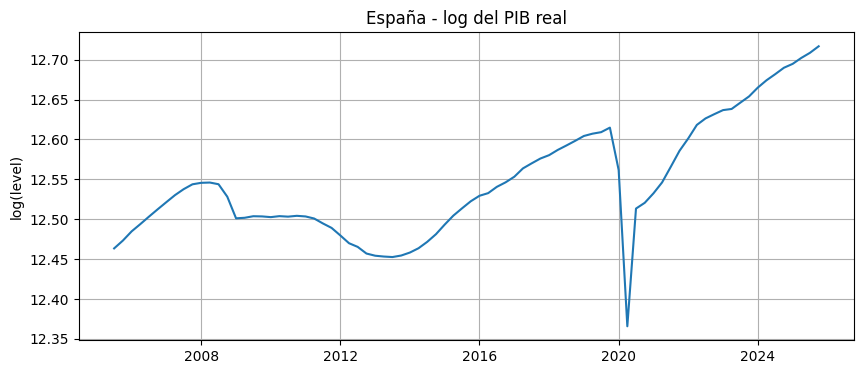

In [234]:
#Parámetros del forecast
FREQ = "Q"
PDT = 4   # 4 trimestres
CTX = 24  # 24 trimestres de contexto
BSZ = 32
PSZ = 8

print("Frequency:", FREQ)
print("Prediction length:", PDT)
print("Context length:", CTX)

#Serie objetivo final
ts = df_model[target_col].copy()

#Forecast para 2026
forecast_start = pd.Period("2026Q1", freq=FREQ)

print("Último dato observado:", ts.index[-1])
print("Forecast empieza en:", forecast_start)

#Visualización rápida de la serie
plt.figure(figsize=(10, 4))
plt.plot(ts.index.to_timestamp(), ts.values)
plt.title("España - log del PIB real")
plt.ylabel("log(nivel)")
plt.ylabel("log(level)")
plt.grid(True)
plt.show()

Convertimos la serie trimestral a un dataframe compatible con el pipeline de forecasting

In [ ]:
!pip install gluonts
from gluonts.dataset.pandas import PandasDataset

In [235]:
FORECAST_START_DATE = "2026Q1" #empiezo a predecir justo después del último dato real
ROLLING_WINDOWS = 1
WINDOW_DISTANCE = 1

df_bistro = df_model.copy()
df_bistro["item_id"] = "spain_gdp"

#ver si la historia es suficiente
if len(df_bistro) <= CTX + PDT:
    raise ValueError(
        f"No hay suficiente historia para CTX={CTX} y PDT={PDT}. "
        f"Observaciones disponibles: {len(df_bistro)}"
    )

prep = prepare_long_df_monthly_for_daily_inference(
    df_bistro,
    item_id_col="item_id",
    target_col=target_col,
    past_dynamic_real_cols=covariate_cols,
    freq=FREQ,
    forecast_start_date=FORECAST_START_DATE,
    pdt_patches=PDT,
    ctx_patches=CTX,
    steps_per_period=PSZ,
    rolling_windows=ROLLING_WINDOWS,
    window_distance_patches=WINDOW_DISTANCE,
)

last_actual_period = prep.df_dt.index.max().to_period(FREQ)

pure_future_forecast = prep.forecast_start > last_actual_period
forecast_windows = 1 if pure_future_forecast else prep.windows

if (not pure_future_forecast) and (prep.windows < 1):
    raise ValueError(
        f"Not enough test data after cutoff {prep.train_end} to create a window: "
        f"test_len={(prep.df_dt.index > prep.cutoff_date_dt).sum()} periods, PDT={PDT}."
    )

ds = PandasDataset.from_long_dataframe(
    prep.daily_long_df,
    item_id="item_id",
    target=target_col,
    past_feat_dynamic_real=covariate_cols,
    feat_dynamic_real=[],
)

#Separamos el data set entre train y test
train, test_template = split(ds, date=prep.cutoff_period_daily)

test_data = test_template.generate_instances(
    prediction_length=prep.pdt_steps,
    windows=forecast_windows,
    distance=prep.dist_steps,
    max_history=prep.ctx_steps,
)

print("Último dato observado:", last_actual_period)
print("Forecast start:", prep.forecast_start)
print("Pure future forecast:", pure_future_forecast)
print("Número de ventanas:", forecast_windows)
print("Prediction length interna:", prep.pdt_steps)
print("Context length interna:", prep.ctx_steps)
print("Número de covariables:", len(covariate_cols))
print("Prediction length (trimestres):", PDT)
print("Context length (trimestres):", CTX)
print("Prediction length interna (steps):", prep.pdt_steps)
print("Context length interna (steps):", prep.ctx_steps)

Último dato observado: 2025Q4
Forecast start: 2026Q1
Pure future forecast: True
Número de ventanas: 1
Prediction length interna: 32
Context length interna: 192
Número de covariables: 10
Prediction length (trimestres): 4
Context length (trimestres): 24
Prediction length interna (steps): 32
Context length interna (steps): 192


###**Step 4**

Ejecutar la predicción con BISTRO sobre el PIB de España incluyendo las covariables y comparar el forecast con los datos reales.

In [236]:
import os
from pathlib import Path

if not Path("/content/bistro").exists():
    !git clone -q https://github.com/bis-med-it/bistro.git /content/bistro

!pip install -q -r /content/bistro/requirements.txt

In [237]:
import os
import sys
from pathlib import Path

os.chdir("/content/bistro/script")

repo_root_bistro = Path("..").resolve()
src_root = Path("../src").resolve()

if str(src_root) not in sys.path:
    sys.path.insert(0, str(src_root))

print("repo_root_bistro:", repo_root_bistro)
print("src_root:", src_root)

repo_root_bistro: /content/bistro
src_root: /content/bistro/src


In [30]:
#IMPORTS

import numpy as np
import pandas as pd
from gluonts.dataset.pandas import PandasDataset
from gluonts.dataset.split import split
from uni2ts.model.moirai import MoiraiForecast, MoiraiModule


In [238]:
#Ejecutamos BISTRO + forecast

MODEL_REPO = Path("/content/bistro/bistro-finetuned")

model = MoiraiForecast(
    module=MoiraiModule.from_pretrained(str(MODEL_REPO)),
    prediction_length=int(prep.pdt_steps),
    context_length=int(prep.ctx_steps),
    patch_size=int(PSZ),
    num_samples=100,
    target_dim=1,
    feat_dynamic_real_dim=0,
    past_feat_dynamic_real_dim=len(covariate_cols),
)

predictor = model.create_predictor(batch_size=BSZ)
inputs = list(test_data.input)
labels = list(test_data.label)
forecasts = list(predictor.predict(test_data.input))

print("Número de forecasts generados:", len(forecasts))

bistro_forecast_by_window = {}
rmse_rows = []

for w in range(forecast_windows):
    samples = np.asarray(forecasts[w].samples, dtype=float)

    if w < len(labels) and isinstance(labels[w], dict) and "target" in labels[w]:
        label_target = np.asarray(labels[w]["target"], dtype=float)
    else:
        label_target = np.asarray([], dtype=float)

    if w < len(inputs) and isinstance(inputs[w], dict) and "target" in inputs[w]:
        inp_target = np.asarray(inputs[w]["target"], dtype=float)
    else:
        inp_target = np.asarray([], dtype=float)

    last_input = float(inp_target[-1]) if inp_target.size > 0 else None

    preds, _, ci = aggregate_daily_forecast_to_monthly(
        samples,
        label_target,
        last_input,
        steps_per_period=PSZ,
        expected_periods=PDT,
    )

    pred_index = pd.period_range(
        start=prep.forecast_start + w * WINDOW_DISTANCE,
        periods=PDT,
        freq=FREQ,
    )

    dfw = pd.DataFrame(
        {
            "bistro_pred": preds,
            "bistro_lo": ci[:, 0],
            "bistro_hi": ci[:, 1]
        },
        index=pred_index,
    )

    bistro_forecast_by_window[w] = dfw

    #En forecast puro futuro no habrá actuals, por lo que *rmse* será NaN
    actual = df_model[target_col].reindex(pred_index).astype(float)
    pred = dfw["bistro_pred"].astype(float)
    valid = actual.notna() & pred.notna()

    rmse = float(np.sqrt(np.mean((pred[valid] - actual[valid]) ** 2))) if valid.any() else np.nan

    rmse_rows.append(
        {
            "window": w,
            "forecast_start": pred_index[0],
            "forecast_end": pred_index[-1],
            "rmse": rmse,
            "n_valid": int(valid.sum()),
        }
    )

rmse_table = pd.DataFrame(rmse_rows)

print("Resumen de ventanas:")
display(rmse_table)

forecast_2026 = bistro_forecast_by_window[0].copy()
forecast_2026 = forecast_2026.loc["2026Q1":"2026Q4"]

#último PIB real observado
last_gdp_real = df_model["gdp_real"].dropna().iloc[-1]

#predicción en log(nivel)
forecast_log = forecast_2026["bistro_pred"].astype(float)

#convertir de log a nivel
forecast_levels = np.exp(forecast_log)

#construir serie completa: último real + forecasts
gdp_levels_all = pd.concat([
    pd.Series([last_gdp_real], index=[df_model.index[-1]]),
    forecast_levels
])

#calcular QoQ correctamente
forecast_qoq = gdp_levels_all.pct_change() * 100
forecast_qoq = forecast_qoq.iloc[1:]

#añadir al dataframe final
forecast_2026["forecast_gdp_level"] = forecast_levels
forecast_2026["forecast_gdp_qoq"] = forecast_qoq

print("Forecast de España para 2026:")
display(forecast_2026)

Loading weights from local directory
Número de forecasts generados: 1
Resumen de ventanas:


,window,forecast_start,forecast_end,rmse,n_valid
0,0,2026Q1,2026Q4,NaN,0


Forecast de España para 2026:


,bistro_pred,bistro_lo,bistro_hi,forecast_gdp_level,forecast_gdp_qoq
2026Q1,12.705759,12.701708,12.709735,329640.883169,-1.104284
2026Q2,12.705976,12.701967,12.710471,329712.449418,0.021710
2026Q3,12.705026,12.700318,12.710062,329399.201597,-0.095006
2026Q4,12.704834,12.700503,12.710852,329336.006707,-0.019185


**BISTRO SIN CONSTRUCCIÓN------------------------------------------------------------------------------------------------**

In [205]:
df1 = pd.concat(
    [
        df_gdp,
        df_ipi_q,
        df_retail_q,
        df_unemp_q,
        df_hicp_q,
        # df_constr_q,
    ],
    axis=1
).sort_index()

df1 = df1.dropna()

print("Primer dato disponible por variable:")
for col in df1.columns:
    print(col, df1[col].first_valid_index())

print("\nDataset limpio:")
print("Inicio:", df1.index.min())
print("Fin:", df1.index.max())
print("Número de observaciones:", len(df1))
display(df.head())
display(df.tail())

Primer dato disponible por variable:
spain_real_gdp 2000Q2
ipi_qoq 2000Q2
retail_qoq 2000Q2
unemp_rate 2000Q2
hicp_yoy 2000Q2

Dataset limpio:
Inicio: 2000Q2
Fin: 2025Q4
Número de observaciones: 103


,spain_real_gdp,ipi_qoq,retail_qoq,unemp_rate,hicp_yoy
date,,,,,
2000Q2,218416.9,-0.247049,1.409112,11.933333,3.233333
2000Q3,220644.6,-0.577876,1.667439,11.800000,3.666667
2000Q4,223006.4,0.027678,2.277904,11.466667,4.033333
2001Q1,225271.0,-0.525733,2.048998,10.666667,2.866667
2001Q2,227022.1,-0.194715,0.742034,10.500000,3.700000


,spain_real_gdp,ipi_qoq,retail_qoq,unemp_rate,hicp_yoy
date,,,,,
2024Q4,324467.2,1.365756,0.884725,10.833333,2.333333
2025Q1,326054.0,0.295761,1.418623,10.866667,2.666667
2025Q2,328474.4,0.557012,1.627670,10.600000,2.166667
2025Q3,330587.9,0.130336,1.126126,10.500000,2.800000
2025Q4,333321.7,0.683371,1.311557,10.100000,3.133333


In [210]:
# DATASET FINAL DEL MODELO SIN CONSTRUCCIÓN
df_model1 = df1.copy()
df_model1 = df_model1.rename(columns={"spain_real_gdp": "gdp_real"})

# Target en log del nivel del PIB
df_model1["log_gdp"] = np.log(df_model1["gdp_real"])
target_col1 = "log_gdp"

# Covariables base SIN construcción
base_covariates1 = [
    "ipi_qoq",
    "retail_qoq",
    "unemp_rate",
    "hicp_yoy"
]

#Crear lags de 1 trimestre
for col in base_covariates1:
    df_model1[f"{col}_l1"] = df_model1[col].shift(1)

#Lista final de covariables
covariate_cols1 = base_covariates1 + [f"{col}_l1" for col in base_covariates1]

#Quedarse solo con columnas necesarias
df_model1 = df_model1[["gdp_real", target_col1] + covariate_cols1]

#Eliminar filas con NaN en target o covariables
df_model1 = df_model1.dropna(subset=[target_col1] + covariate_cols1)

print("Número de observaciones finales:", len(df_model1))
print("Primer periodo:", df_model1.index.min())
print("Último periodo:", df_model1.index.max())
display(df_model1.head())
display(df_model1.tail())

Número de observaciones finales: 102
Primer periodo: 2000Q3
Último periodo: 2025Q4


,gdp_real,log_gdp,ipi_qoq,retail_qoq,unemp_rate,hicp_yoy,ipi_qoq_l1,retail_qoq_l1,unemp_rate_l1,hicp_yoy_l1
date,,,,,,,,,,
2000Q3,220644.6,12.304309,-0.577876,1.667439,11.800000,3.666667,-0.247049,1.409112,11.933333,3.233333
2000Q4,223006.4,12.314956,0.027678,2.277904,11.466667,4.033333,-0.577876,1.667439,11.800000,3.666667
2001Q1,225271.0,12.325059,-0.525733,2.048998,10.666667,2.866667,0.027678,2.277904,11.466667,4.033333
2001Q2,227022.1,12.332803,-0.194715,0.742034,10.500000,3.700000,-0.525733,2.048998,10.666667,2.866667
2001Q3,229204.6,12.342370,0.418060,2.079723,10.533333,2.266667,-0.194715,0.742034,10.500000,3.700000


,gdp_real,log_gdp,ipi_qoq,retail_qoq,unemp_rate,hicp_yoy,ipi_qoq_l1,retail_qoq_l1,unemp_rate_l1,hicp_yoy_l1
date,,,,,,,,,,
2024Q4,324467.2,12.689940,1.365756,0.884725,10.833333,2.333333,-0.793126,1.104972,11.266667,2.333333
2025Q1,326054.0,12.694818,0.295761,1.418623,10.866667,2.666667,1.365756,0.884725,10.833333,2.333333
2025Q2,328474.4,12.702214,0.557012,1.627670,10.600000,2.166667,0.295761,1.418623,10.866667,2.666667
2025Q3,330587.9,12.708628,0.130336,1.126126,10.500000,2.800000,0.557012,1.627670,10.600000,2.166667
2025Q4,333321.7,12.716863,0.683371,1.311557,10.100000,3.133333,0.130336,1.126126,10.500000,2.800000


In [211]:
FORECAST_START_DATE1 = "2026Q1"
ROLLING_WINDOWS1 = 1
WINDOW_DISTANCE1 = 1

df_bistro1 = df_model1.copy()
df_bistro1["item_id"] = "spain_gdp"

if len(df_bistro1) <= CTX + PDT:
    raise ValueError(
        f"No hay suficiente historia para CTX={CTX} y PDT={PDT}. "
        f"Observaciones disponibles: {len(df_bistro1)}"
    )

prep1 = prepare_long_df_monthly_for_daily_inference(
    df_bistro1,
    item_id_col="item_id",
    target_col=target_col1,
    past_dynamic_real_cols=covariate_cols1,
    freq=FREQ,
    forecast_start_date=FORECAST_START_DATE1,
    pdt_patches=PDT,
    ctx_patches=CTX,
    steps_per_period=PSZ,
    rolling_windows=ROLLING_WINDOWS1,
    window_distance_patches=WINDOW_DISTANCE1,
)

last_actual_period1 = prep1.df_dt.index.max().to_period(FREQ)
pure_future_forecast1 = prep1.forecast_start > last_actual_period1
forecast_windows1 = 1 if pure_future_forecast1 else prep1.windows

if (not pure_future_forecast1) and (prep1.windows < 1):
    raise ValueError(
        f"Not enough test data after cutoff {prep1.train_end} to create a window: "
        f"test_len={(prep1.df_dt.index > prep1.cutoff_date_dt).sum()} periods, PDT={PDT}."
    )

ds1 = PandasDataset.from_long_dataframe(
    prep1.daily_long_df,
    item_id="item_id",
    target=target_col1,
    past_feat_dynamic_real=covariate_cols1,
    feat_dynamic_real=[],
)

train1, test_template1 = split(ds1, date=prep1.cutoff_period_daily)

test_data1 = test_template1.generate_instances(
    prediction_length=prep1.pdt_steps,
    windows=forecast_windows1,
    distance=prep1.dist_steps,
    max_history=prep1.ctx_steps,
)

print("Último dato observado:", last_actual_period1)
print("Forecast start:", prep1.forecast_start)
print("Pure future forecast:", pure_future_forecast1)
print("Número de ventanas:", forecast_windows1)
print("Prediction length interna:", prep1.pdt_steps)
print("Context length interna:", prep1.ctx_steps)
print("Número de covariables:", len(covariate_cols1))

Último dato observado: 2025Q4
Forecast start: 2026Q1
Pure future forecast: True
Número de ventanas: 1
Prediction length interna: 32
Context length interna: 160
Número de covariables: 8


In [212]:
# Ejecutamos BISTRO SIN CONSTRUCCIÓN

MODEL_REPO = Path("/content/bistro/bistro-finetuned")

model1 = MoiraiForecast(
    module=MoiraiModule.from_pretrained(str(MODEL_REPO)),
    prediction_length=int(prep1.pdt_steps),
    context_length=int(prep1.ctx_steps),
    patch_size=int(PSZ),
    num_samples=100,
    target_dim=1,
    feat_dynamic_real_dim=0,
    past_feat_dynamic_real_dim=len(covariate_cols1),
)

predictor1 = model1.create_predictor(batch_size=BSZ)
inputs1 = list(test_data1.input)
labels1 = list(test_data1.label)
forecasts1 = list(predictor1.predict(test_data1.input))

print("Número de forecasts generados:", len(forecasts1))

bistro_forecast_by_window1 = {}
rmse_rows1 = []

for w in range(forecast_windows1):
    samples1 = np.asarray(forecasts1[w].samples, dtype=float)

    if w < len(labels1) and isinstance(labels1[w], dict) and "target" in labels1[w]:
        label_target1 = np.asarray(labels1[w]["target"], dtype=float)
    else:
        label_target1 = np.asarray([], dtype=float)

    if w < len(inputs1) and isinstance(inputs1[w], dict) and "target" in inputs1[w]:
        inp_target1 = np.asarray(inputs1[w]["target"], dtype=float)
    else:
        inp_target1 = np.asarray([], dtype=float)

    last_input1 = float(inp_target1[-1]) if inp_target1.size > 0 else None

    preds1, _, ci1 = aggregate_daily_forecast_to_monthly(
        samples1,
        label_target1,
        last_input1,
        steps_per_period=PSZ,
        expected_periods=PDT,
    )

    pred_index1 = pd.period_range(
        start=prep1.forecast_start + w * WINDOW_DISTANCE1,
        periods=PDT,
        freq=FREQ,
    )

    dfw1 = pd.DataFrame(
        {
            "bistro_pred": preds1,
            "bistro_lo": ci1[:, 0],
            "bistro_hi": ci1[:, 1]
        },
        index=pred_index1,
    )

    bistro_forecast_by_window1[w] = dfw1

    # En forecast puro futuro no habrá actuals, por lo que rmse será NaN
    actual1 = df_model1[target_col1].reindex(pred_index1).astype(float)
    pred1 = dfw1["bistro_pred"].astype(float)
    valid1 = actual1.notna() & pred1.notna()

    rmse1 = float(np.sqrt(np.mean((pred1[valid1] - actual1[valid1]) ** 2))) if valid1.any() else np.nan

    rmse_rows1.append(
        {
            "window": w,
            "forecast_start": pred_index1[0],
            "forecast_end": pred_index1[-1],
            "rmse": rmse1,
            "n_valid": int(valid1.sum()),
        }
    )

rmse_table1 = pd.DataFrame(rmse_rows1)

print("Resumen de ventanas:")
display(rmse_table1)

forecast_2026_1 = bistro_forecast_by_window1[0].copy()
forecast_2026_1 = forecast_2026_1.loc["2026Q1":"2026Q4"]

# último PIB real observado
last_gdp_real1 = df_model1["gdp_real"].dropna().iloc[-1]

# predicción en log(nivel)
forecast_log1 = forecast_2026_1["bistro_pred"].astype(float)

# convertir de log a nivel
forecast_levels1 = np.exp(forecast_log1)

# construir serie completa: último real + forecasts
gdp_levels_all1 = pd.concat([
    pd.Series([last_gdp_real1], index=[df_model1.index[-1]]),
    forecast_levels1
])

# calcular QoQ correctamente
forecast_qoq1 = gdp_levels_all1.pct_change() * 100
forecast_qoq1 = forecast_qoq1.iloc[1:]

# añadir al dataframe final
forecast_2026_1["forecast_gdp_level"] = forecast_levels1
forecast_2026_1["forecast_gdp_qoq"] = forecast_qoq1

print("Forecast de España para 2026 - SIN construcción:")
display(forecast_2026_1)

Loading weights from local directory
Número de forecasts generados: 1
Resumen de ventanas:


,window,forecast_start,forecast_end,rmse,n_valid
0,0,2026Q1,2026Q4,NaN,0


Forecast de España para 2026 - SIN construcción:


,bistro_pred,bistro_lo,bistro_hi,forecast_gdp_level,forecast_gdp_qoq
2026Q1,12.706158,12.702892,12.710361,329772.335699,-1.064846
2026Q2,12.706145,12.701661,12.711182,329768.070382,-0.001293
2026Q3,12.705615,12.702129,12.710567,329593.318484,-0.052992
2026Q4,12.705474,12.699605,12.711132,329546.958854,-0.014066


| Característica | Con construcción | Sin construcción |
| -------------- | ---------------- | ---------------- |
| Observaciones  | 82               | 102              |
| Inicio         | 2005             | 2000             |
| Ruido          | Alto             | Bajo             |
| Estabilidad    | Peor             | Mejor            |


**------------------------------------------------------------------------------------------------------------------**

In [243]:
# LIMPIAMOS Y PREPARAMOS EL DATASET FINAL PARA EL MODELO
df_model = df.copy()
df_model = df_model.rename(columns={"spain_real_gdp": "gdp_real"})

# Target en log del nivel del PIB
df_model["log_gdp"] = np.log(df_model["gdp_real"])
target_col = "log_gdp"

# Covariables base
base_covariates = [
    "ipi_qoq",
    "retail_qoq",
    "unemp_rate",
    "hicp_yoy"
]

# SIN lags: usar solo variables actuales
covariate_cols = base_covariates.copy()

# Quedarse solo con columnas necesarias
df_model = df_model[["gdp_real", target_col] + covariate_cols]

# Eliminar filas con NaN en target o covariables
df_model = df_model.dropna(subset=[target_col] + covariate_cols)

# histórico en QoQ
gdp_levels = df_model["gdp_real"]
gdp_qoq_hist = gdp_levels.pct_change() * 100

print("Número de observaciones finales:", len(df_model))
print("Primer periodo:", df_model.index.min())
print("Último periodo:", df_model.index.max())
display(df_model.head())
display(df_model.tail())

Número de observaciones finales: 83
Primer periodo: 2005Q2
Último periodo: 2025Q4


,gdp_real,log_gdp,ipi_qoq,retail_qoq,unemp_rate,hicp_yoy
date,,,,,,
2005Q2,256254.0,12.453924,1.144102,1.339915,9.400000,3.266667
2005Q3,258708.4,12.463457,0.350121,0.208768,8.633333,3.466667
2005Q4,261261.8,12.473278,0.402576,1.527778,8.700000,3.533333
2006Q1,264301.4,12.484845,2.138466,1.846785,8.733333,4.066667
2006Q2,266680.2,12.493805,0.392567,1.343183,8.500000,4.000000


,gdp_real,log_gdp,ipi_qoq,retail_qoq,unemp_rate,hicp_yoy
date,,,,,,
2024Q4,324467.2,12.689940,1.365756,0.884725,10.833333,2.333333
2025Q1,326054.0,12.694818,0.295761,1.418623,10.866667,2.666667
2025Q2,328474.4,12.702214,0.557012,1.627670,10.600000,2.166667
2025Q3,330587.9,12.708628,0.130336,1.126126,10.500000,2.800000
2025Q4,333321.7,12.716863,0.683371,1.311557,10.100000,3.133333


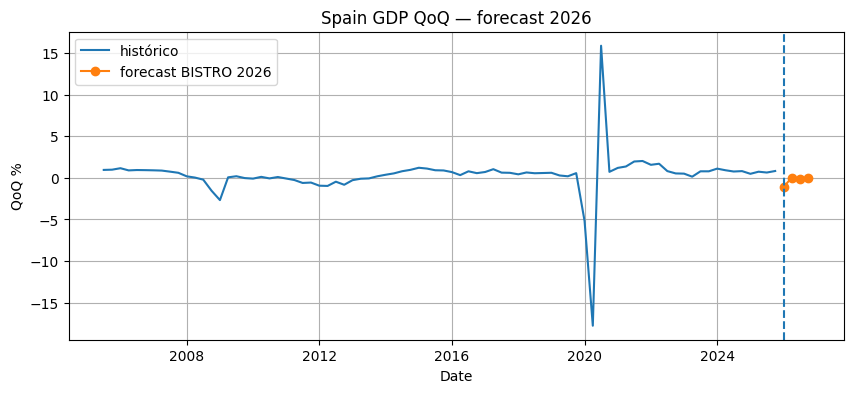

In [244]:
#Gráfico del forecast 2026

import matplotlib.pyplot as plt
import pandas as pd

hist = df_model[target_col].copy()

plt.figure(figsize=(10, 4))

# histórico QoQ
plt.plot(gdp_qoq_hist.index.to_timestamp(), gdp_qoq_hist.values, label="histórico")

# forecast QoQ
plt.plot(
    forecast_2026.index.to_timestamp(),
    forecast_2026["forecast_gdp_qoq"].values,
    marker="o",
    label="forecast BISTRO 2026"
)

# línea vertical inicio forecast
plt.axvline(x=forecast_2026.index[0].to_timestamp(), linestyle="--")

plt.title("Spain GDP QoQ — forecast 2026")
plt.xlabel("Date")
plt.ylabel("QoQ %")
plt.legend()
plt.grid(True)
plt.show()

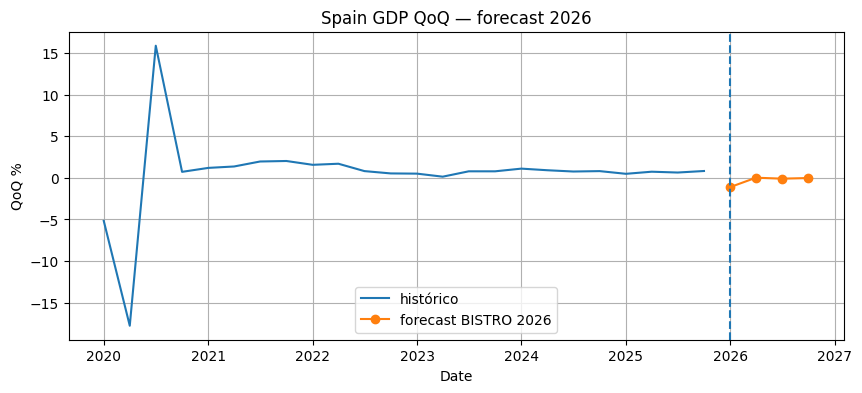

In [246]:
plot_start = pd.Period("2020Q1", freq="Q")

hist_plot = gdp_qoq_hist[gdp_qoq_hist.index >= plot_start]
forecast_plot = forecast_2026[forecast_2026.index >= plot_start]

plt.figure(figsize=(10, 4))

plt.plot(
    hist_plot.index.to_timestamp(),
    hist_plot.values,
    label="histórico"
)

plt.plot(
    forecast_plot.index.to_timestamp(),
    forecast_plot["forecast_gdp_qoq"].values,
    marker="o",
    label="forecast BISTRO 2026"
)

plt.axvline(x=forecast_2026.index[0].to_timestamp(), linestyle="--")

plt.title("Spain GDP QoQ — forecast 2026")
plt.xlabel("Date")
plt.ylabel("QoQ %")
plt.legend()
plt.grid(True)
plt.show()

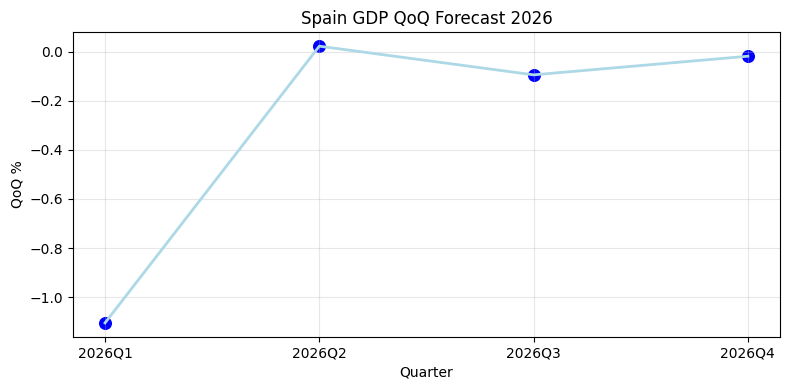

In [248]:
import matplotlib.pyplot as plt

x = forecast_2026.index.astype(str)
y = forecast_2026["forecast_gdp_qoq"].values

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x, y, linewidth=2, color="lightblue")
ax.scatter(x, y, s=70, color="blue")
ax.set_title("Spain GDP QoQ Forecast 2026")
ax.set_xlabel("Quarter")
ax.set_ylabel("QoQ %")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [249]:
print("Número de observaciones:", len(df_model))
print("Primer periodo:", df_model.index.min())
print("Último periodo:", df_model.index.max())
print()
print(df_model[covariate_cols].isna().sum())

Número de observaciones: 83
Primer periodo: 2005Q2
Último periodo: 2025Q4

ipi_qoq       0
retail_qoq    0
unemp_rate    0
hicp_yoy      0
dtype: int64
